In [1]:
import sys
sys.path.append('..')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

#from src.preprocessing import load_and_preprocess, inverse_target
#from src.dataset import make_dataloaders
#from src.models.lstm import LSTMBaseline, train_epoch, eval_epoch
#from src.metrics import evaluate_persistence, evaluate_model, print_results



SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [ ]:
df_raw = pd.read_csv("data/jena_climate_2009_2017.csv")

# Parse datetime index
df_raw['Date Time'] = pd.to_datetime(df_raw['Date Time'], format='%d.%m.%Y %H:%M:%S')
df_raw = df_raw.set_index('Date Time').sort_index()

print(f'Shape:      {df_raw.shape}')
print(f'Date range: {df_raw.index.min()} → {df_raw.index.max()}')
print(f'Columns:    {list(df_raw.columns)}')
df_raw.head()

Shape:      (420551, 6)
Date range: 2009-01-01 00:10:00 → 2017-01-01 00:00:00
Columns:    ['p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'T (degC)']


,p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg),T (degC)
Date Time,,,,,,
2009-01-01 00:10:00,996.52,93.3,1.03,1.75,152.3,-8.02
2009-01-01 00:20:00,996.57,93.4,0.72,1.50,136.1,-8.41
2009-01-01 00:30:00,996.53,93.9,0.19,0.63,171.6,-8.51
2009-01-01 00:40:00,996.51,94.2,0.34,0.50,198.0,-8.31
2009-01-01 00:50:00,996.51,94.1,0.32,0.63,214.3,-8.27


EDA

In [4]:
# missing values and basic stats
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'None')
print()
df_raw.describe().round(3)

Missing values per column:
None



,p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg),T (degC)
count,420551.000,420551.000,420551.000,420551.000,420551.000,420551.000
mean,989.213,76.008,1.702,3.057,174.744,9.450
std,8.358,16.476,65.447,69.017,86.682,8.423
min,913.600,12.950,-9999.000,-9999.000,0.000,-23.010
25%,984.200,65.210,0.990,1.760,124.900,3.360
50%,989.580,79.300,1.760,2.960,198.100,9.420
75%,994.720,89.400,2.860,4.740,234.100,15.470
max,1015.350,100.000,28.490,23.500,360.000,37.280


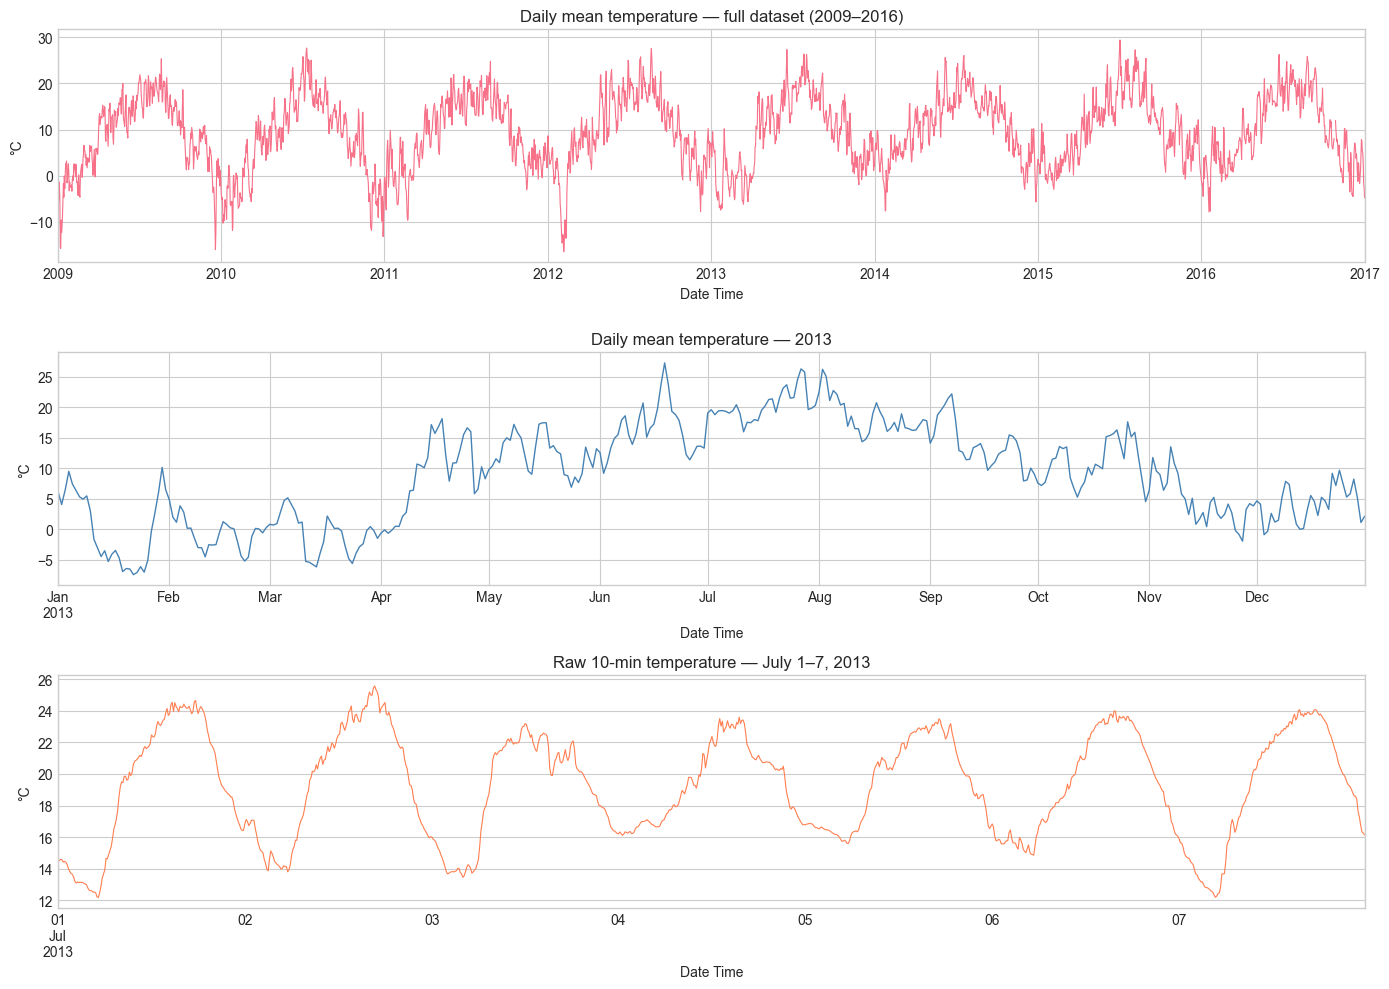

In [5]:
# temperature at 3 resolutions
temp_col = 'T (degC)'

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# full dataset
df_raw[temp_col].resample('D').mean().plot(ax=axes[0], lw=0.8)
axes[0].set_title('Daily mean temperature — full dataset (2009–2016)', fontsize=12)
axes[0].set_ylabel('°C')

# one year
df_raw.loc['2013', temp_col].resample('D').mean().plot(ax=axes[1], color='steelblue', lw=1)
axes[1].set_title('Daily mean temperature — 2013', fontsize=12)
axes[1].set_ylabel('°C')

# one of raw 10-min data
df_raw.loc['2013-07-01':'2013-07-07', temp_col].plot(ax=axes[2], color='coral', lw=0.8)
axes[2].set_title('Raw 10-min temperature — July 1–7, 2013', fontsize=12)
axes[2].set_ylabel('°C')

plt.tight_layout()
plt.savefig('eda_temperature_resolutions.png', dpi=150, bbox_inches='tight')
plt.show()

#this is confirming that the data has structure (summers are hotter, weekly patterns)

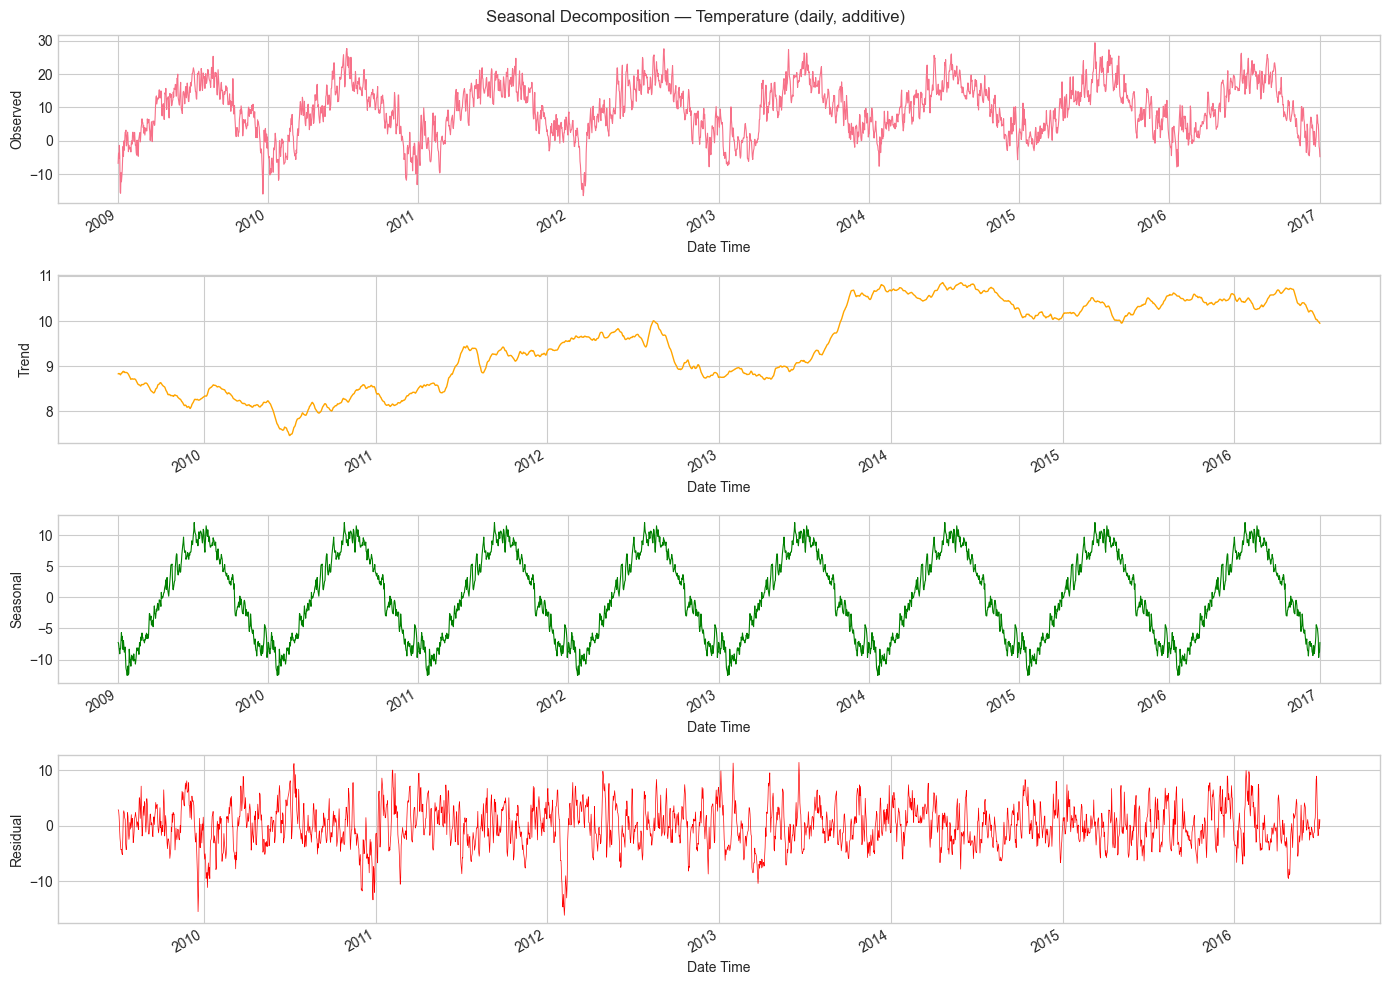

In [6]:
# splits temperature into trend, seasonal, and residual components

from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to hourly first
df_hourly = df_raw.resample('1h').mean()

# trend - is it getting warmer over the years overall?
# seasonal - the repeating yearly pattern
# residual - everything left over
decomp_series = df_hourly[temp_col].resample('D').mean().dropna()
result = seasonal_decompose(decomp_series, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
result.observed.plot(ax=axes[0], lw=0.8); axes[0].set_ylabel('Observed')
result.trend.plot(ax=axes[1], lw=1, color='orange'); axes[1].set_ylabel('Trend')
result.seasonal.plot(ax=axes[2], lw=0.8, color='green'); axes[2].set_ylabel('Seasonal')
result.resid.plot(ax=axes[3], lw=0.5, color='red'); axes[3].set_ylabel('Residual')
fig.suptitle('Seasonal Decomposition — Temperature (daily, additive)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

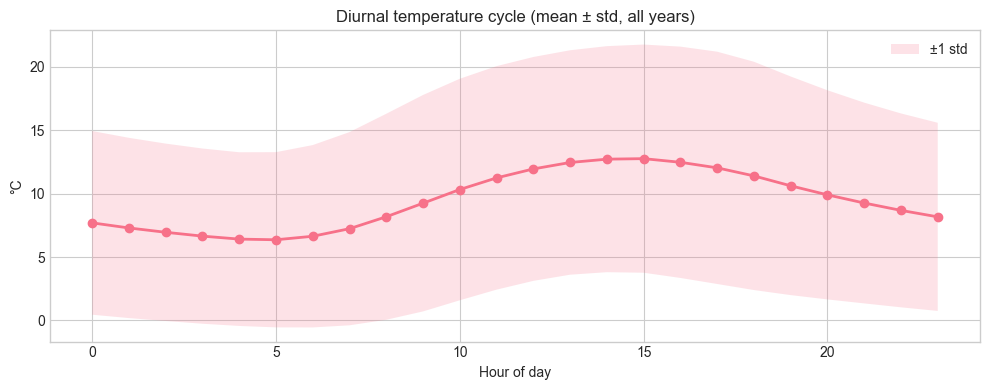

In [7]:
# groups all data by hour of day and plots the average temperature at each hour across all years
df_hourly['hour'] = df_hourly.index.hour

diurnal = df_hourly.groupby('hour')[temp_col].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(diurnal.index, diurnal['mean'], marker='o', lw=2)
ax.fill_between(diurnal.index,
                diurnal['mean'] - diurnal['std'],
                diurnal['mean'] + diurnal['std'],
                alpha=0.2, label='±1 std')
ax.set_xlabel('Hour of day')
ax.set_ylabel('°C')
ax.set_title('Diurnal temperature cycle (mean ± std, all years)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_diurnal.png', dpi=150, bbox_inches='tight')
plt.show()

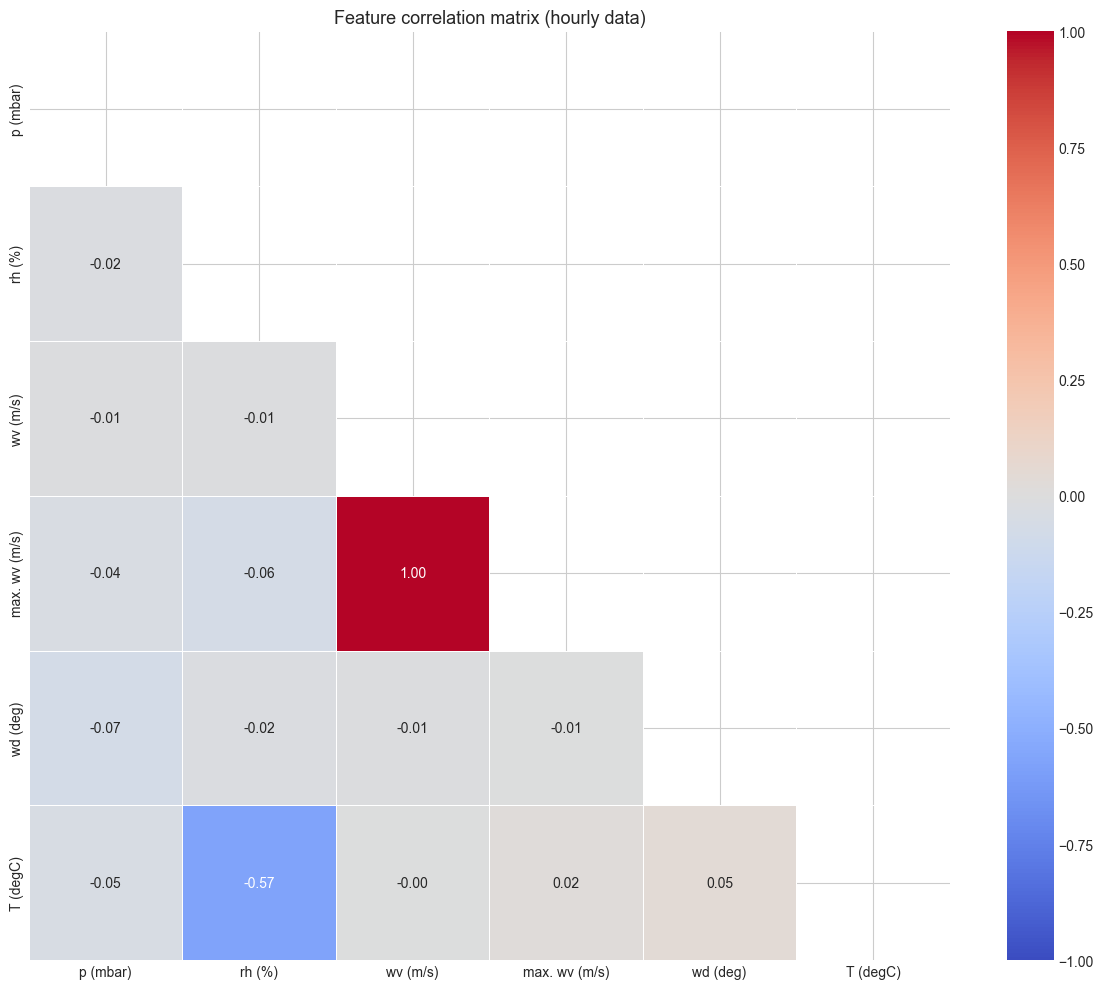

In [8]:
# shows how strongly each pair of features is related to each other
df_hourly_clean = df_hourly.drop(columns=['hour'], errors='ignore')

# wind direction is circular — drop wv and max. wv outliers check
# replace physically impossible wind values (-9999) with NaN
df_hourly_clean = df_hourly_clean.replace(-9999.0, np.nan)

corr = df_hourly_clean.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature correlation matrix (hourly data)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

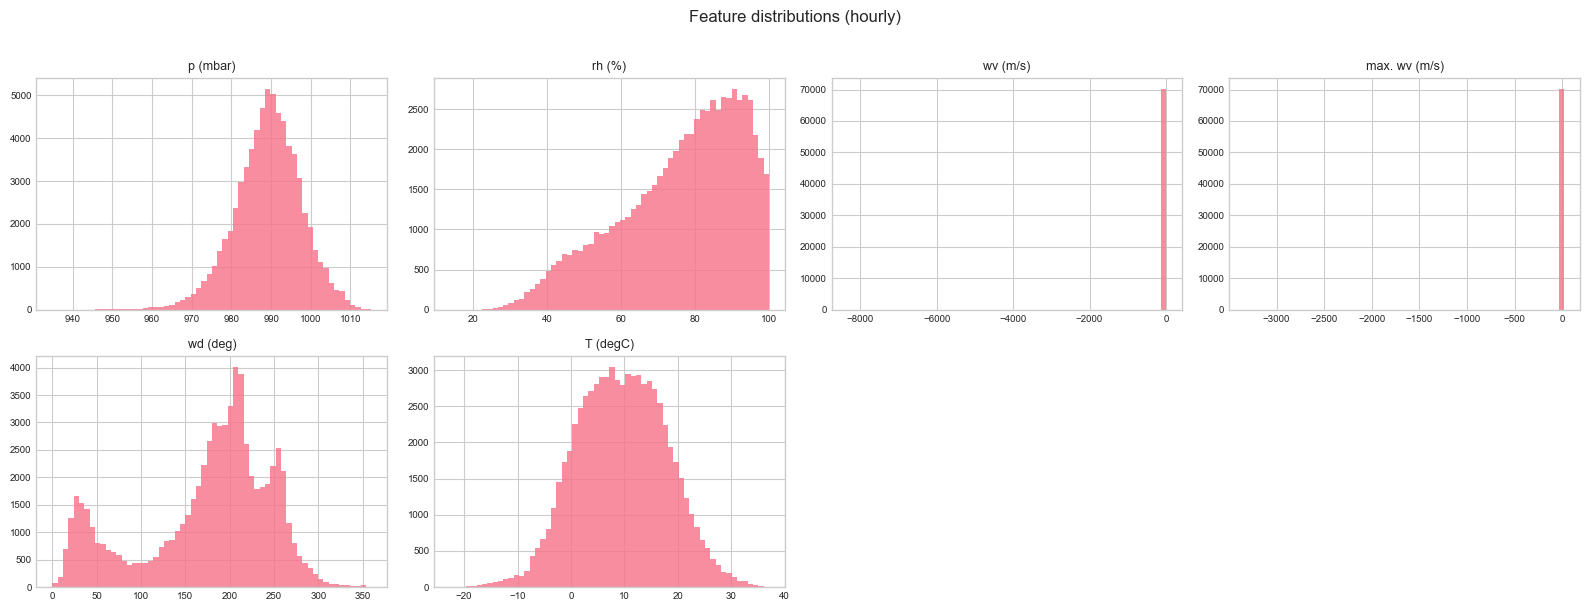

In [9]:
# plots a histogram of each feature
cols = df_hourly_clean.columns.tolist()
n = len(cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df_hourly_clean[col].dropna(), bins=60, edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature distributions (hourly)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Preprocessing

In [10]:
# ── 4.1 Resample to hourly & clean ────────────────────────────────────────────
df = df_raw.copy()

# Replace bad wind values
df = df.replace(-9999.0, np.nan)

# Resample to hourly (mean)
df = df.resample('1h').mean()

# Linear interpolation for remaining NaNs (typically <0.1%)
df = df.interpolate(method='linear', limit=6)  # max 6-hour gap
df = df.dropna()

print(f'Hourly shape: {df.shape}')
print(f'Any NaN: {df.isnull().any().any()}')

Hourly shape: (70053, 6)
Any NaN: False


In [11]:
# ── 4.2 Wind direction: encode as (sin, cos) to preserve circularity ──────────
if 'wd (deg)' in df.columns:
    df['wd_sin'] = np.sin(np.deg2rad(df['wd (deg)']))
    df['wd_cos'] = np.cos(np.deg2rad(df['wd (deg)']))
    df = df.drop(columns=['wd (deg)'])
    print('Wind direction encoded as sin/cos')

# Time features (useful for TFT later as known future inputs)
df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['doy_sin']  = np.sin(2 * np.pi * df.index.dayofyear / 365)
df['doy_cos']  = np.cos(2 * np.pi * df.index.dayofyear / 365)

FEATURE_COLS = df.columns.tolist()
TARGET_COL   = 'T (degC)'

print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Wind direction encoded as sin/cos
Total features: 11
['p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'T (degC)', 'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


In [12]:
# ── 4.3 Train / val / test split (chronological, no shuffle) ──────────────────
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print(f'Train: {df_train.index.min().date()} → {df_train.index.max().date()}  ({len(df_train):,} rows)')
print(f'Val:   {df_val.index.min().date()} → {df_val.index.max().date()}  ({len(df_val):,} rows)')
print(f'Test:  {df_test.index.min().date()} → {df_test.index.max().date()}  ({len(df_test):,} rows)')

Train: 2009-01-01 → 2014-08-06  (49,037 rows)
Val:   2014-08-06 → 2015-10-18  (10,508 rows)
Test:  2015-10-18 → 2017-01-01  (10,508 rows)


In [13]:
# ── 4.4 Normalise (fit scaler on train only) ───────────────────────────────────
scaler = StandardScaler()
scaler.fit(df_train[FEATURE_COLS])

train_arr = scaler.transform(df_train[FEATURE_COLS])
val_arr   = scaler.transform(df_val[FEATURE_COLS])
test_arr  = scaler.transform(df_test[FEATURE_COLS])

# Store the index of the target column for inverse-transform later
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
print(f'Target column index: {TARGET_IDX}  ({TARGET_COL})')

# Helper to inverse-transform predictions back to °C
target_mean = scaler.mean_[TARGET_IDX]
target_std  = scaler.scale_[TARGET_IDX]

def inverse_target(arr):
    return arr * target_std + target_mean

Target column index: 4  (T (degC))


Sliding Window Dataset

In [14]:
# Forecasting config
INPUT_LEN  = 24 * 7   # 1 week of history
HORIZON    = 24       # predict next 24 hours  (change for ablations)
STEP       = 1        # slide 1 hour at a time

class TimeSeriesDataset(Dataset):
    """
    Sliding window dataset.
    Returns (X, y) where:
        X : (input_len, n_features)  — past observations
        y : (horizon,)               — future target values
    """
    def __init__(self, data: np.ndarray, input_len: int, horizon: int,
                 target_idx: int, step: int = 1):
        self.data       = torch.FloatTensor(data)
        self.input_len  = input_len
        self.horizon    = horizon
        self.target_idx = target_idx
        self.step       = step
        self.indices    = range(0, len(data) - input_len - horizon + 1, step)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        x = self.data[start : start + self.input_len]                        # (T, F)
        y = self.data[start + self.input_len :                                # (H,)
                      start + self.input_len + self.horizon, self.target_idx]
        return x, y


# Build datasets
train_ds = TimeSeriesDataset(train_arr, INPUT_LEN, HORIZON, TARGET_IDX, step=6)
val_ds   = TimeSeriesDataset(val_arr,   INPUT_LEN, HORIZON, TARGET_IDX, step=6)
test_ds  = TimeSeriesDataset(test_arr,  INPUT_LEN, HORIZON, TARGET_IDX, step=6)

BATCH_SIZE = 512
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train samples: {len(train_ds):,}')
print(f'Val   samples: {len(val_ds):,}')
print(f'Test  samples: {len(test_ds):,}')

# Sanity check shapes
xb, yb = next(iter(train_loader))
print(f'Batch X: {xb.shape}  (batch, input_len, features)')
print(f'Batch y: {yb.shape}  (batch, horizon)')

Train samples: 8,141
Val   samples: 1,720
Test  samples: 1,720
Batch X: torch.Size([512, 168, 11])  (batch, input_len, features)
Batch y: torch.Size([512, 24])  (batch, horizon)


Baseline 1: Persistence Model

In [15]:
def evaluate_persistence(loader, target_idx, inverse_fn):
    """
    For each window, predict y = last value of the input sequence (repeated).
    Returns MAE and RMSE in original units (°C).
    """
    all_preds, all_targets = [], []

    for x, y in loader:
        last_val = x[:, -1, target_idx].unsqueeze(1).expand_as(y)  # (B, H)
        all_preds.append(last_val.numpy())
        all_targets.append(y.numpy())

    preds   = inverse_fn(np.concatenate(all_preds,   axis=0))  # (N, H)
    targets = inverse_fn(np.concatenate(all_targets, axis=0))  # (N, H)

    mae  = mean_absolute_error(targets.flatten(), preds.flatten())
    rmse = np.sqrt(mean_squared_error(targets.flatten(), preds.flatten()))

    # Per-horizon metrics
    mae_per_h  = [mean_absolute_error(targets[:, h], preds[:, h]) for h in range(targets.shape[1])]
    rmse_per_h = [np.sqrt(mean_squared_error(targets[:, h], preds[:, h])) for h in range(targets.shape[1])]

    return preds, targets, mae, rmse, mae_per_h, rmse_per_h


p_preds, p_targets, p_mae, p_rmse, p_mae_h, p_rmse_h = evaluate_persistence(
    test_loader, TARGET_IDX, inverse_target
)

print(f'Persistence — Test MAE:  {p_mae:.4f} °C')
print(f'Persistence — Test RMSE: {p_rmse:.4f} °C')

Persistence — Test MAE:  3.1129 °C
Persistence — Test RMSE: 4.2071 °C


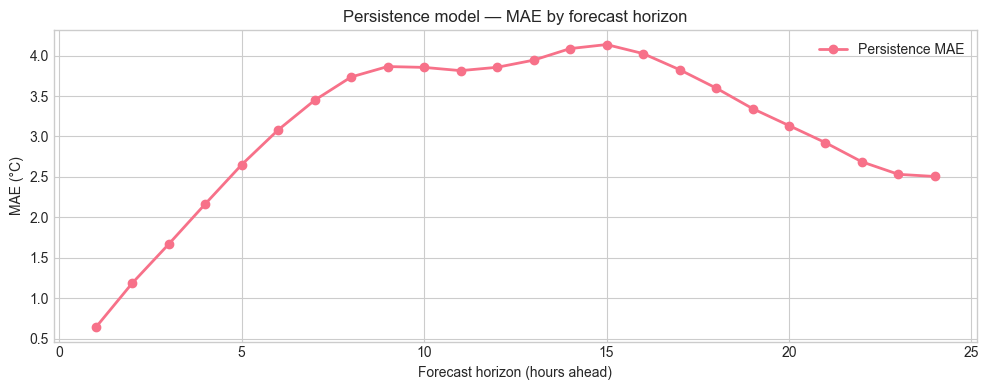

In [16]:
# Per-horizon MAE plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, HORIZON + 1), p_mae_h, marker='o', label='Persistence MAE', lw=2)
ax.set_xlabel('Forecast horizon (hours ahead)')
ax.set_ylabel('MAE (°C)')
ax.set_title('Persistence model — MAE by forecast horizon')
ax.legend()
plt.tight_layout()
plt.savefig('baseline_persistence_mae.png', dpi=150, bbox_inches='tight')
plt.show()

Baseline 2: Simple LSTM

In [17]:
class LSTMBaseline(nn.Module):
    """
    Single-layer LSTM encoder → linear decoder.
    Input:  (B, T, F)
    Output: (B, H)
    """
    def __init__(self, input_size: int, hidden_size: int, horizon: int,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)   # h_n: (num_layers, B, hidden)
        out = self.head(h_n[-1])      # take last layer hidden state → (B, H)
        return out


N_FEATURES  = len(FEATURE_COLS)
HIDDEN_SIZE = 128
NUM_LAYERS  = 2

lstm_model = LSTMBaseline(
    input_size=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    horizon=HORIZON,
    num_layers=NUM_LAYERS,
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'LSTM parameters: {total_params:,}')
print(lstm_model)

LSTM parameters: 207,384
LSTMBaseline(
  (lstm): LSTM(11, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=128, out_features=24, bias=True)
)


In [18]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x)
        total_loss += criterion(pred, y).item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        all_preds.append(model(x).cpu().numpy())
        all_targets.append(y.numpy())
    preds   = inverse_target(np.concatenate(all_preds,   axis=0))
    targets = inverse_target(np.concatenate(all_targets, axis=0))
    return preds, targets

In [19]:
# ── Training loop ──────────────────────────────────────────────────────────────
N_EPOCHS   = 30
LR         = 1e-3
criterion  = nn.HuberLoss(delta=1.0)   # robust to outliers
optimizer  = Adam(lstm_model.parameters(), lr=LR, weight_decay=1e-5)
scheduler  = ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, N_EPOCHS + 1):
    tr_loss  = train_epoch(lstm_model, train_loader, optimizer, criterion)
    val_loss = eval_epoch(lstm_model,  val_loader,   criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(lstm_model.state_dict(), 'lstm_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | train: {tr_loss:.5f} | val: {val_loss:.5f}')

print(f'\nBest val loss: {best_val_loss:.5f}')

/Users/sakshi/Downloads/cs273p_final_project/venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch   1/30 | train: 0.32868 | val: 0.18901
Epoch   5/30 | train: 0.05229 | val: 0.05103
Epoch  10/30 | train: 0.04183 | val: 0.04337
Epoch  15/30 | train: 0.03937 | val: 0.04176
Epoch  20/30 | train: 0.03798 | val: 0.04084
Epoch  25/30 | train: 0.03616 | val: 0.04023
Epoch  30/30 | train: 0.03533 | val: 0.03953

Best val loss: 0.03930


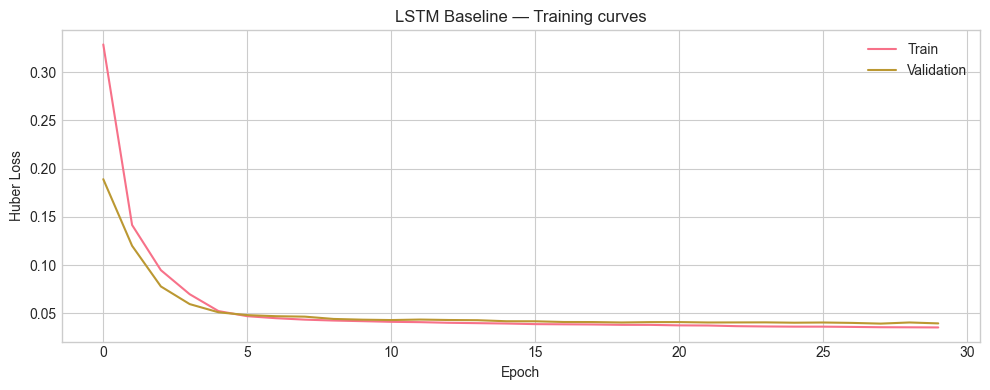

In [20]:
# ── Learning curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses,   label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.set_title('LSTM Baseline — Training curves')
ax.legend()
plt.tight_layout()
plt.savefig('lstm_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── Load best checkpoint & evaluate on test set ────────────────────────────────
lstm_model.load_state_dict(torch.load('lstm_best.pt', map_location=DEVICE))

lstm_preds, lstm_targets = get_predictions(lstm_model, test_loader)

lstm_mae  = mean_absolute_error(lstm_targets.flatten(), lstm_preds.flatten())
lstm_rmse = np.sqrt(mean_squared_error(lstm_targets.flatten(), lstm_preds.flatten()))

lstm_mae_h  = [mean_absolute_error(lstm_targets[:, h], lstm_preds[:, h]) for h in range(HORIZON)]
lstm_rmse_h = [np.sqrt(mean_squared_error(lstm_targets[:, h], lstm_preds[:, h])) for h in range(HORIZON)]

print(f'LSTM Baseline — Test MAE:  {lstm_mae:.4f} °C')
print(f'LSTM Baseline — Test RMSE: {lstm_rmse:.4f} °C')

LSTM Baseline — Test MAE:  1.8000 °C
LSTM Baseline — Test RMSE: 2.3447 °C


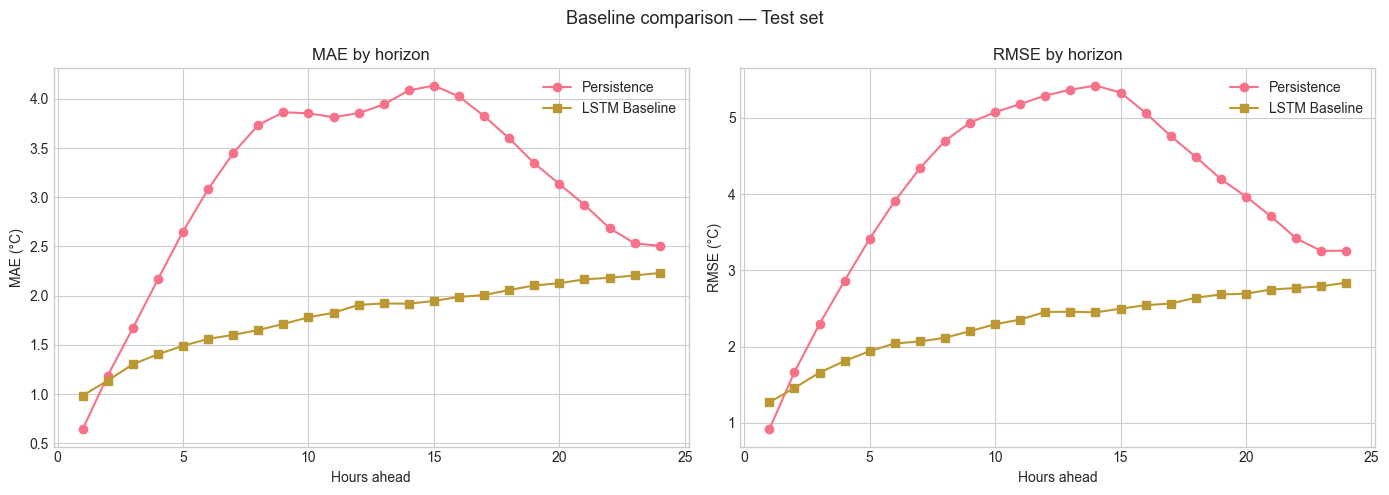

In [22]:
# ── Compare baselines per horizon ─────────────────────────────────────────────
horizons = list(range(1, HORIZON + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(horizons, p_mae_h,    marker='o', label='Persistence')
axes[0].plot(horizons, lstm_mae_h, marker='s', label='LSTM Baseline')
axes[0].set_title('MAE by horizon')
axes[0].set_xlabel('Hours ahead')
axes[0].set_ylabel('MAE (°C)')
axes[0].legend()

axes[1].plot(horizons, p_rmse_h,    marker='o', label='Persistence')
axes[1].plot(horizons, lstm_rmse_h, marker='s', label='LSTM Baseline')
axes[1].set_title('RMSE by horizon')
axes[1].set_xlabel('Hours ahead')
axes[1].set_ylabel('RMSE (°C)')
axes[1].legend()

plt.suptitle('Baseline comparison — Test set', fontsize=13)
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

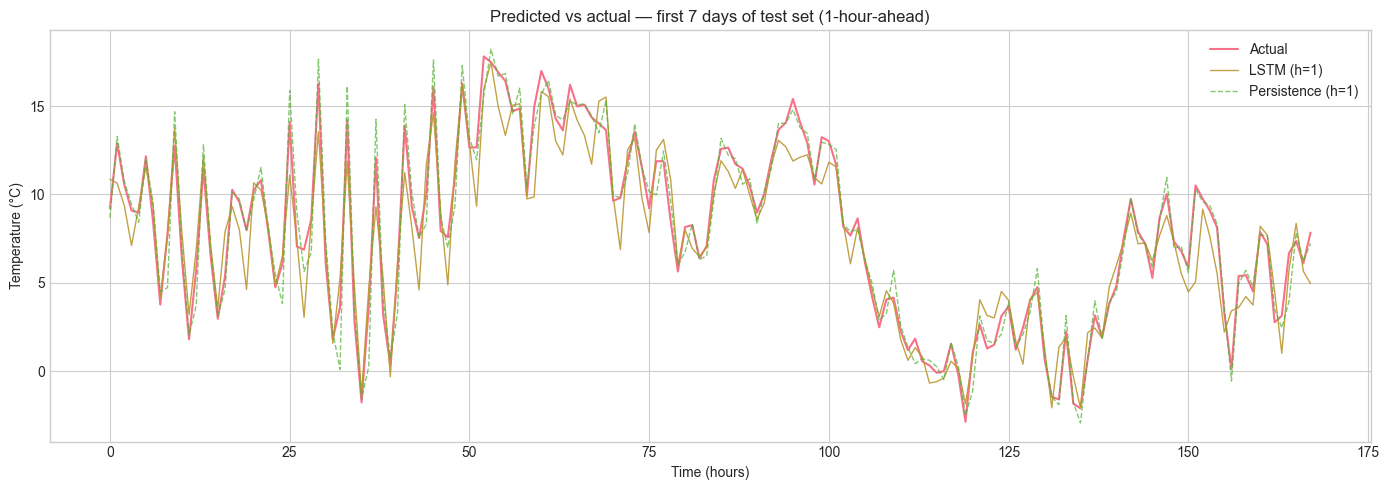

In [23]:
# ── Qualitative: predicted vs actual (first 7 days of test set) ───────────────
n_samples_plot = 7 * 24   # 7 days of hourly predictions (1-step-ahead only)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lstm_targets[:n_samples_plot, 0], label='Actual',           lw=1.5)
ax.plot(lstm_preds[:n_samples_plot,   0], label='LSTM (h=1)',       lw=1, alpha=0.9)
ax.plot(p_preds[:n_samples_plot,      0], label='Persistence (h=1)',lw=1, alpha=0.7, linestyle='--')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Predicted vs actual — first 7 days of test set (1-hour-ahead)')
ax.legend()
plt.tight_layout()
plt.savefig('baseline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

Results

In [24]:
def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

results = pd.DataFrame([
    {
        'Model':       'Persistence',
        'MAE (°C)':    round(p_mae,    4),
        'RMSE (°C)':   round(p_rmse,   4),
        'MAPE (%)':    round(mape(p_targets.flatten(), p_preds.flatten()), 2),
    },
    {
        'Model':       'LSTM Baseline',
        'MAE (°C)':    round(lstm_mae,    4),
        'RMSE (°C)':   round(lstm_rmse,   4),
        'MAPE (%)':    round(mape(lstm_targets.flatten(), lstm_preds.flatten()), 2),
    },
])

results = results.set_index('Model')
print('=== Phase 1 Baseline Results (Test Set) ===')
print(results.to_string())
results

=== Phase 1 Baseline Results (Test Set) ===
               MAE (°C)  RMSE (°C)  MAPE (%)
Model                                       
Persistence      3.1129     4.2071    119.54
LSTM Baseline    1.8000     2.3447     83.18


,MAE (°C),RMSE (°C),MAPE (%)
Model,,,
Persistence,3.1129,4.2071,119.54
LSTM Baseline,1.8000,2.3447,83.18


In [25]:
# Save results to CSV for the report
results.to_csv('phase1_baseline_results.csv')
print('Saved: phase1_baseline_results.csv')
print('\nPhase 1 complete. Targets for Phase 2 (TFT) to beat:')
print(f'  MAE  < {lstm_mae:.3f} °C')
print(f'  RMSE < {lstm_rmse:.3f} °C')

Saved: phase1_baseline_results.csv

Phase 1 complete. Targets for Phase 2 (TFT) to beat:
  MAE  < 1.800 °C
  RMSE < 2.345 °C
